# Name: Danish Zaheer
# Roll no: 25280092

In [1]:
# Imports all libraries used
import time
import copy
import random
from pathlib import Path
from types import MethodType
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.models import resnet152, ResNet152_Weights
from torchvision.transforms import InterpolationMode
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

In [2]:
# Sets the random seed and selects CPU or GPU execution.
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Device name:", torch.cuda.get_device_name(device) if device.type == "cuda" else "CPU")

Using device: cuda
Device name: NVIDIA GeForce RTX 3060 Laptop GPU


## 1) Baseline setup

In [3]:
# Loads the ImageNet-pretrained ResNet-152 preprocessing.
# Downloads and prepares the CIFAR-10 training dataset.
weights = ResNet152_Weights.DEFAULT
preprocess = weights.transforms()
full_dataset = datasets.CIFAR10(root="../Data",train=True,download=True,transform=preprocess)
print("Number of images:", len(full_dataset))
print("Classes:", full_dataset.classes)

Number of images: 50000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


c:\Users\DanishZaheer\anaconda3\envs\ATML\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5980392..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.0125492].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6330532..1.9602616].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240347..2.0996952].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.570283

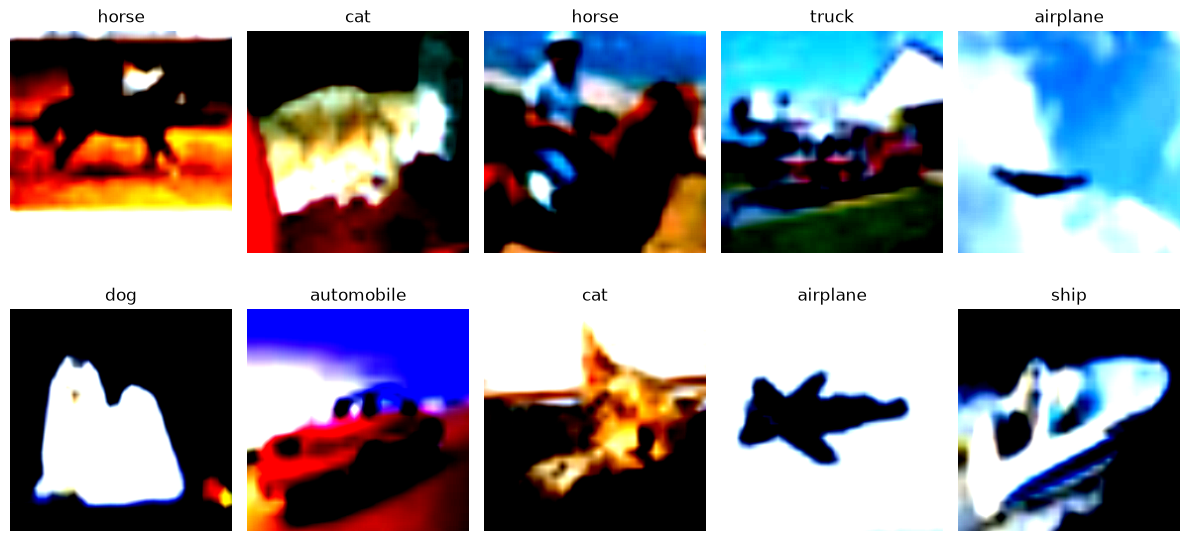

In [4]:
# Displays a small random sample of CIFAR-10 images.
# Uses the dataset class names to label each subplot.
class_names = full_dataset.classes
sample_indices = random.sample(range(len(full_dataset)), 10)
plt.figure(figsize=(12, 6))

for position, index in enumerate(sample_indices):
    image, label = full_dataset[index]
    image = image.permute(1, 2, 0)
    plt.subplot(2, 5, position + 1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Splits CIFAR-10 into training and validation sets.
# Creates DataLoaders used by the baseline experiment.
train_size = 45000
val_size = 5000
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))
batch_size = 32
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,num_workers=0)
val_loader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False,num_workers=0)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 45000
Validation images: 5000


In [6]:
# Builds the pretrained ResNet-152 baseline model.
# Freezes the backbone and replaces the final classifier.
model = resnet152(weights=weights)
for parameter in model.parameters():
    parameter.requires_grad = False

number_of_features = model.fc.in_features
model.fc = nn.Linear(number_of_features, 10)
model = model.to(device)
print(model.fc)

Linear(in_features=2048, out_features=10, bias=True)


In [7]:
# Counts total and trainable parameters in the baseline.
# Confirms that only the new classifier is trainable.
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters())
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad)

print(f"Total parameters:     {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Total parameters:     58,164,298
Trainable parameters: 20,490


In [8]:
# Creates the baseline loss function and optimizer.
# Optimizes only the replaced fully connected layer.
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.fc.parameters(),lr=0.001)

In [9]:
# Defines one training or validation pass for the baseline.
# Returns average loss and accuracy for a DataLoader.
def run_epoch(data_loader, training):
    if training:
        model.eval()
        model.fc.train()
    else:
        model.eval()

    total_loss = 0
    total_correct = 0
    total_images = 0
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            if training:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if training:
                loss.backward()
                optimizer.step()

            predictions = outputs.argmax(dim=1)
            total_loss += loss.item() * images.size(0)
            total_correct += (predictions == labels).sum().item()
            total_images += labels.size(0)

    average_loss = total_loss / total_images
    accuracy = total_correct / total_images
    return average_loss, accuracy

In [10]:
# Trains the baseline model with checkpoint resume support.
# Saves model, optimizer, and history after every epoch.
epochs = 10
progress_dir = Path("./training_progress_model_1")
progress_dir.mkdir(exist_ok=True)
checkpoint_path = progress_dir / "latest_checkpoint.pth"
start_epoch = 0

if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    history = checkpoint["history"]
    start_epoch = checkpoint["epoch"]
    print(f"Resuming training from epoch {start_epoch + 1}")
else:
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []}
    print("Starting training from epoch 1")

for epoch in range(start_epoch, epochs):
    train_loss, train_accuracy = run_epoch(train_loader, training=True)
    val_loss, val_accuracy = run_epoch(val_loader, training=False)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    checkpoint = {
        "epoch": epoch + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "history": history}
    
    torch.save(checkpoint, checkpoint_path)
    print(f"Epoch {epoch + 1}/{epochs}")
    print(
        f"Train - Loss: {train_loss:.4f}, "
        f"Accuracy: {train_accuracy * 100:.2f}%")
    print(
        f"Val   - Loss: {val_loss:.4f}, "
        f"Accuracy: {val_accuracy * 100:.2f}%")
    print(f"Checkpoint saved to {checkpoint_path}")
    print("-" * 50)

if start_epoch >= epochs:
    print("Training is already complete for the selected number of epochs.")

Resuming training from epoch 11
Training is already complete for the selected number of epochs.


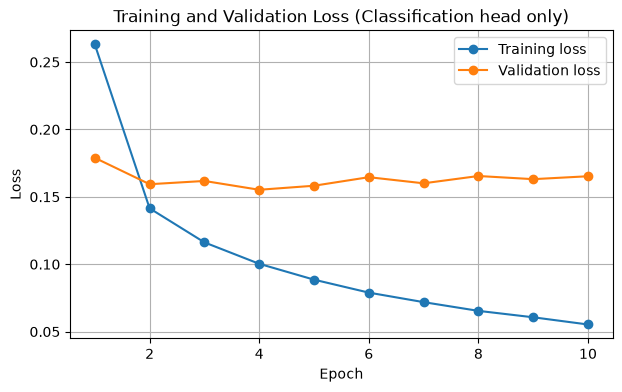

In [11]:
# Plots baseline training and validation loss.
# Uses the saved history collected during training.
epoch_numbers = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(
    epoch_numbers,
    history["train_loss"],
    marker="o",
    label="Training loss")
plt.plot(
    epoch_numbers,
    history["val_loss"],
    marker="o",
    label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (Classification head only)")
plt.legend()
plt.grid()
plt.show()

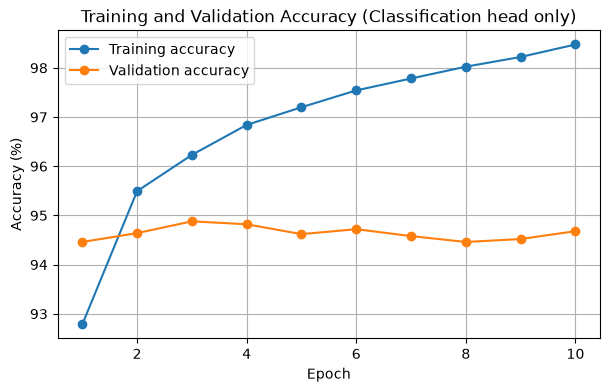

In [12]:
# Plots baseline training and validation accuracy.
# Converts accuracy values to percentages for display.
plt.figure(figsize=(7, 4))
plt.plot(
    epoch_numbers,
    [accuracy * 100 for accuracy in history["train_accuracy"]],
    marker="o",
    label="Training accuracy")

plt.plot(
    epoch_numbers,
    [accuracy * 100 for accuracy in history["val_accuracy"]],
    marker="o",
    label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy (Classification head only)")
plt.legend()
plt.grid()
plt.show()

In [13]:
# Prints the baseline metrics for every completed epoch.
# Summarizes loss and accuracy from the saved history.
for epoch in range(len(history["train_loss"])):
    print(
        f"Epoch {epoch + 1}: "
        f"train_loss={history['train_loss'][epoch]:.4f}, "
        f"train_acc={history['train_accuracy'][epoch] * 100:.2f}%, "
        f"val_loss={history['val_loss'][epoch]:.4f}, "
        f"val_acc={history['val_accuracy'][epoch] * 100:.2f}%")

Epoch 1: train_loss=0.2630, train_acc=92.78%, val_loss=0.1789, val_acc=94.46%
Epoch 2: train_loss=0.1415, train_acc=95.49%, val_loss=0.1594, val_acc=94.64%
Epoch 3: train_loss=0.1162, train_acc=96.23%, val_loss=0.1618, val_acc=94.88%
Epoch 4: train_loss=0.1003, train_acc=96.84%, val_loss=0.1552, val_acc=94.82%
Epoch 5: train_loss=0.0885, train_acc=97.20%, val_loss=0.1582, val_acc=94.62%
Epoch 6: train_loss=0.0789, train_acc=97.54%, val_loss=0.1646, val_acc=94.72%
Epoch 7: train_loss=0.0719, train_acc=97.78%, val_loss=0.1600, val_acc=94.58%
Epoch 8: train_loss=0.0654, train_acc=98.02%, val_loss=0.1654, val_acc=94.46%
Epoch 9: train_loss=0.0606, train_acc=98.22%, val_loss=0.1631, val_acc=94.52%
Epoch 10: train_loss=0.0553, train_acc=98.48%, val_loss=0.1653, val_acc=94.68%


## 2) Residual Connections in Practice

In [14]:
# Stores a separate copy of the baseline history.
# Moves unused models off the GPU before the no-skip experiment.
baseline_history = copy.deepcopy(history)
model = model.to("cpu")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Baseline history saved.")
print("Baseline epochs:", len(baseline_history["train_loss"]))

Baseline history saved.
Baseline epochs: 10


In [15]:
# Defines a Bottleneck forward pass without residual addition.
# Keeps the convolutional branch while removing the skip path.
def forward_without_skip(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)
    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)
    out = self.conv3(out)
    out = self.bn3(out)
    out = self.relu(out)
    return out

In [16]:
# Creates a fresh ResNet-152 model for the no-skip test.
# Replaces selected residual block forward methods.
torch.manual_seed(42)
modified_model = resnet152(weights=weights)
selected_blocks = {
    "layer2_last": modified_model.layer2[-1],
    "layer4_last": modified_model.layer4[-1],}

for block_name, block in selected_blocks.items():
    block.forward = MethodType(forward_without_skip, block)
    print("Skip connection disabled in:", block_name)

Skip connection disabled in: layer2_last
Skip connection disabled in: layer4_last


In [17]:
# Freezes the modified backbone and replaces its classifier.
# Moves the no-skip model to the selected device.
for parameter in modified_model.parameters():
    parameter.requires_grad = False

number_of_features = modified_model.fc.in_features
modified_model.fc = nn.Linear(number_of_features, 10)
modified_model = modified_model.to(device)
print(modified_model.fc)

Linear(in_features=2048, out_features=10, bias=True)


In [18]:
# Counts trainable parameters in the no-skip model.
# Runs a small forward-pass sanity check on one batch.
modified_total_parameters = sum(
    parameter.numel()
    for parameter in modified_model.parameters())

modified_trainable_parameters = sum(
    parameter.numel()
    for parameter in modified_model.parameters()
    if parameter.requires_grad)

print(f"Total parameters:     {modified_total_parameters:,}")
print(f"Trainable parameters: {modified_trainable_parameters:,}")

test_images, _ = next(iter(train_loader))
test_images = test_images[:2].to(device)
modified_model.eval()

with torch.no_grad():
    test_outputs = modified_model(test_images)

print("Input shape: ", test_images.shape)
print("Output shape:", test_outputs.shape)

del test_images, test_outputs
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Total parameters:     58,164,298
Trainable parameters: 20,490
Input shape:  torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 10])


In [19]:
# Creates the no-skip loss function and optimizer.
# Optimizes only the modified model classifier head.
modified_criterion = nn.CrossEntropyLoss()
modified_optimizer = torch.optim.AdamW(modified_model.fc.parameters(),lr=0.001)

In [20]:
# Defines one training or validation pass for the no-skip model.
# Returns average loss and accuracy for the modified network.
def run_modified_epoch(data_loader, training):
    if training:
        modified_model.eval()
        modified_model.fc.train()
    else:
        modified_model.eval()

    total_loss = 0
    total_correct = 0
    total_images = 0
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            if training:
                modified_optimizer.zero_grad()

            outputs = modified_model(images)
            loss = modified_criterion(outputs, labels)

            if training:
                loss.backward()
                modified_optimizer.step()

            predictions = outputs.argmax(dim=1)
            total_loss += loss.item() * images.size(0)
            total_correct += (predictions == labels).sum().item()
            total_images += labels.size(0)

    average_loss = total_loss / total_images
    accuracy = total_correct / total_images
    return average_loss, accuracy

In [21]:
# Trains the no-skip model with checkpoint resume support.
# Saves modified-model progress after every epoch.
modified_epochs = 10
modified_progress_dir = Path("./training_progress_model_2")
modified_progress_dir.mkdir(exist_ok=True)
modified_checkpoint_path = modified_progress_dir / "latest_checkpoint.pth"
modified_start_epoch = 0

if modified_checkpoint_path.exists():
    modified_checkpoint = torch.load(
        modified_checkpoint_path,
        map_location=device)

    modified_model.load_state_dict(modified_checkpoint["model_state"])
    modified_optimizer.load_state_dict(modified_checkpoint["optimizer_state"])
    modified_history = modified_checkpoint["history"]
    modified_start_epoch = modified_checkpoint["epoch"]
    print(
        f"Resuming modified-model training from epoch "
        f"{modified_start_epoch + 1}")
else:
    modified_history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []}
    print("Starting modified-model training from epoch 1")

for epoch in range(modified_start_epoch, modified_epochs):
    train_loss, train_accuracy = run_modified_epoch(train_loader,training=True)
    val_loss, val_accuracy = run_modified_epoch(val_loader,training=False)

    modified_history["train_loss"].append(train_loss)
    modified_history["train_accuracy"].append(train_accuracy)
    modified_history["val_loss"].append(val_loss)
    modified_history["val_accuracy"].append(val_accuracy)

    modified_checkpoint = {
        "epoch": epoch + 1,
        "model_state": modified_model.state_dict(),
        "optimizer_state": modified_optimizer.state_dict(),
        "history": modified_history,
        "disabled_skip_blocks": list(selected_blocks.keys())}
    
    torch.save(modified_checkpoint, modified_checkpoint_path)
    print(f"Epoch {epoch + 1}/{modified_epochs}")
    print(
        f"Train - Loss: {train_loss:.4f}, "
        f"Accuracy: {train_accuracy * 100:.2f}%")
    print(
        f"Val   - Loss: {val_loss:.4f}, "
        f"Accuracy: {val_accuracy * 100:.2f}%")
    print(f"Checkpoint saved to {modified_checkpoint_path}")
    print("-" * 50)

if modified_start_epoch >= modified_epochs:
    print(
        "Modified-model training is already complete for the "
        "selected number of epochs.")

Resuming modified-model training from epoch 11
Modified-model training is already complete for the selected number of epochs.


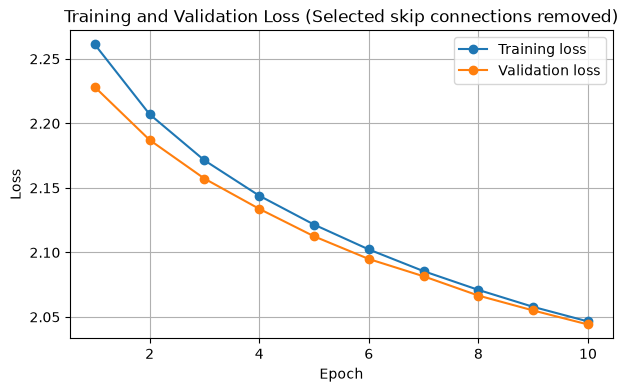

In [22]:
plt.figure(figsize=(7, 4))

epoch_numbers = range(1, len(modified_history["train_loss"]) + 1)

plt.plot(
    epoch_numbers,
    modified_history["train_loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    epoch_numbers,
    modified_history["val_loss"],
    marker="o",
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (Selected skip connections removed)")
plt.legend()
plt.grid()
plt.show()

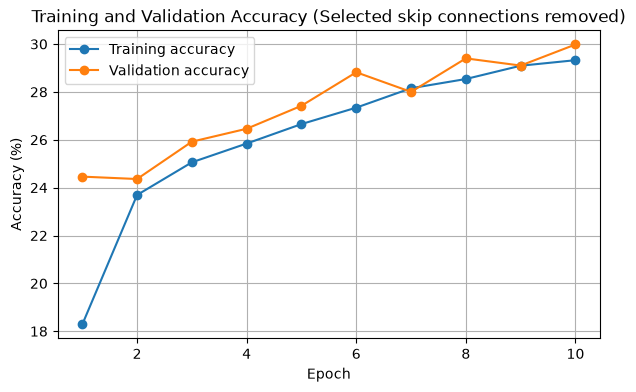

In [23]:
plt.figure(figsize=(7, 4))

plt.plot(
    epoch_numbers,
    [accuracy * 100 for accuracy in modified_history["train_accuracy"]],
    marker="o",
    label="Training accuracy"
)

plt.plot(
    epoch_numbers,
    [accuracy * 100 for accuracy in modified_history["val_accuracy"]],
    marker="o",
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy (Selected skip connections removed)")
plt.legend()
plt.grid()
plt.show()

In [24]:
# Prints a side-by-side baseline and no-skip comparison.
# Compares validation accuracy and loss across matching epochs.
comparison_epochs = min(
    len(baseline_history["val_loss"]),
    len(modified_history["val_loss"]))

print(
    f"{'Epoch':<8}"
    f"{'Baseline Val Acc':<20}"
    f"{'No-Skip Val Acc':<20}"
    f"{'Baseline Val Loss':<20}"
    f"{'No-Skip Val Loss':<20}")
print("-" * 88)

for epoch in range(comparison_epochs):
    print(
        f"{epoch + 1:<8}"
        f"{baseline_history['val_accuracy'][epoch] * 100:<20.2f}"
        f"{modified_history['val_accuracy'][epoch] * 100:<20.2f}"
        f"{baseline_history['val_loss'][epoch]:<20.4f}"
        f"{modified_history['val_loss'][epoch]:<20.4f}")

Epoch   Baseline Val Acc    No-Skip Val Acc     Baseline Val Loss   No-Skip Val Loss    
----------------------------------------------------------------------------------------
1       94.46               24.46               0.1789              2.2282              
2       94.64               24.36               0.1594              2.1871              
3       94.88               25.92               0.1618              2.1572              
4       94.82               26.46               0.1552              2.1338              
5       94.62               27.42               0.1582              2.1125              
6       94.72               28.82               0.1646              2.0949              
7       94.58               28.00               0.1600              2.0815              
8       94.46               29.40               0.1654              2.0666              
9       94.52               29.10               0.1631              2.0550              
10      94.68        

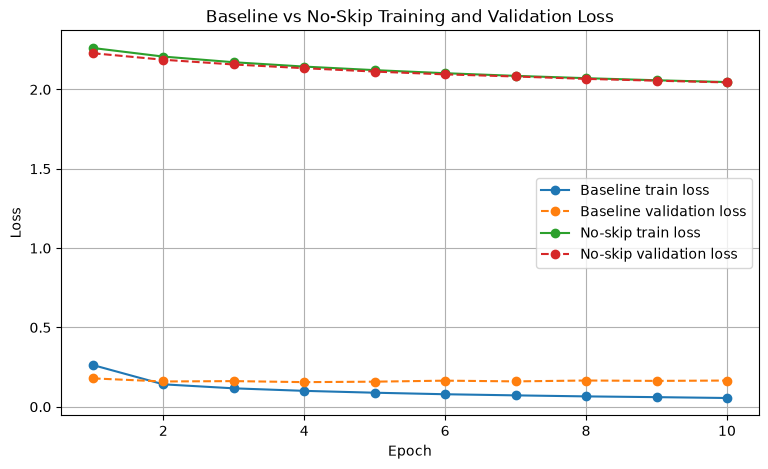

In [25]:
# Plots baseline versus no-skip training and validation loss.
# Uses only epochs available for both experiments.
comparison_epoch_numbers = range(1, comparison_epochs + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    comparison_epoch_numbers,
    baseline_history["train_loss"][:comparison_epochs],
    marker="o",
    linestyle="-",
    label="Baseline train loss"
)

plt.plot(
    comparison_epoch_numbers,
    baseline_history["val_loss"][:comparison_epochs],
    marker="o",
    linestyle="--",
    label="Baseline validation loss"
)

plt.plot(
    comparison_epoch_numbers,
    modified_history["train_loss"][:comparison_epochs],
    marker="o",
    linestyle="-",
    label="No-skip train loss"
)

plt.plot(
    comparison_epoch_numbers,
    modified_history["val_loss"][:comparison_epochs],
    marker="o",
    linestyle="--",
    label="No-skip validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline vs No-Skip Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

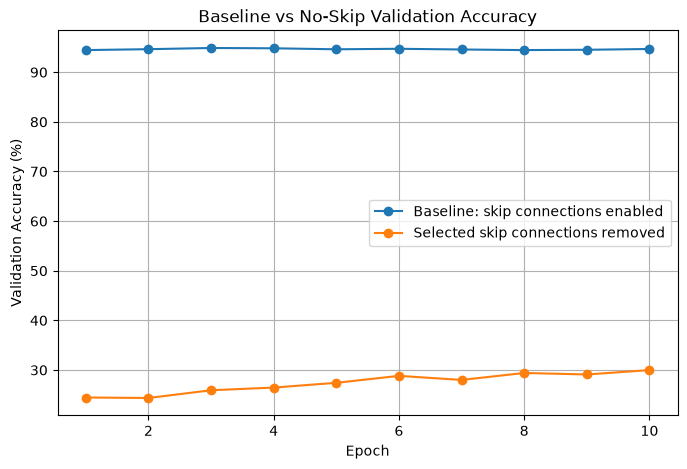

In [26]:
# Plots baseline versus no-skip validation accuracy.
# Shows how removing selected skip connections changes performance.
baseline_val_accuracy = [
    accuracy * 100
    for accuracy in baseline_history["val_accuracy"][:comparison_epochs]]

modified_val_accuracy = [
    accuracy * 100
    for accuracy in modified_history["val_accuracy"][:comparison_epochs]]

plt.figure(figsize=(8, 5))
plt.plot(
    comparison_epoch_numbers,
    baseline_val_accuracy,
    marker="o",
    label="Baseline: skip connections enabled")

plt.plot(
    comparison_epoch_numbers,
    modified_val_accuracy,
    marker="o",
    label="Selected skip connections removed")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Baseline vs No-Skip Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

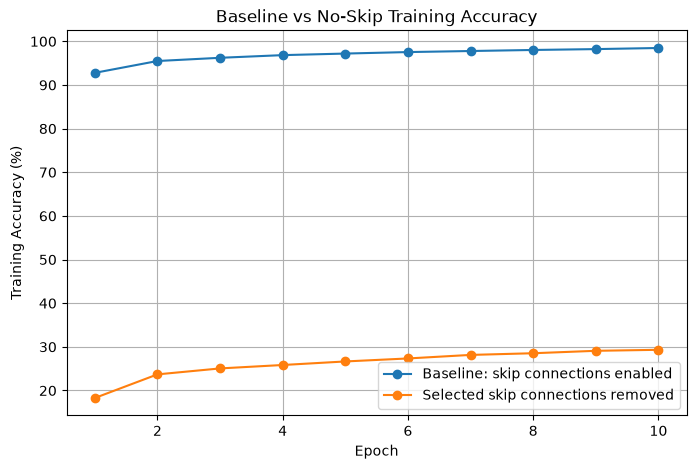

In [27]:
# Plots baseline versus no-skip training accuracy.
# Compares training dynamics across the shared epoch range.
baseline_train_accuracy = [
    accuracy * 100
    for accuracy in baseline_history["train_accuracy"][:comparison_epochs]]

modified_train_accuracy = [
    accuracy * 100
    for accuracy in modified_history["train_accuracy"][:comparison_epochs]]

plt.figure(figsize=(8, 5))
plt.plot(
    comparison_epoch_numbers,
    baseline_train_accuracy,
    marker="o",
    label="Baseline: skip connections enabled")

plt.plot(
    comparison_epoch_numbers,
    modified_train_accuracy,
    marker="o",
    label="Selected skip connections removed")

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Baseline vs No-Skip Training Accuracy")
plt.legend()
plt.grid()
plt.show()

In [28]:
# Prints the final validation-accuracy comparison.
# Saves the final modified model weights to disk.
if comparison_epochs > 0:
    baseline_final_accuracy = (
        baseline_history["val_accuracy"][comparison_epochs - 1] * 100)
    modified_final_accuracy = (
        modified_history["val_accuracy"][comparison_epochs - 1] * 100)
    accuracy_difference = (
        modified_final_accuracy - baseline_final_accuracy)

    print(
        f"Baseline final validation accuracy: "
        f"{baseline_final_accuracy:.2f}%")
    print(
        f"No-skip final validation accuracy:  "
        f"{modified_final_accuracy:.2f}%")
    print(
        f"Difference (no-skip - baseline):     "
        f"{accuracy_difference:.2f} percentage points")

final_model_path = modified_progress_dir / "resnet152_no_skip_final.pth"
torch.save(modified_model.state_dict(), final_model_path)
print(f"Final modified model saved to {final_model_path}")

Baseline final validation accuracy: 94.68%
No-skip final validation accuracy:  29.98%
Difference (no-skip - baseline):     -64.70 percentage points
Final modified model saved to training_progress_model_2\resnet152_no_skip_final.pth


## 3) Feature Hierarchies and Representations

In [29]:
# Restores the trained baseline model for feature analysis.
# Moves unused models off the GPU before collecting activations.
if "modified_model" in globals():
    modified_model = modified_model.to("cpu")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

baseline_model = model.to(device)

if checkpoint_path.exists():
    baseline_checkpoint = torch.load(
        checkpoint_path,
        map_location=device)

    baseline_model.load_state_dict(
        baseline_checkpoint["model_state"])

    print(
        "Loaded baseline checkpoint from:",
        checkpoint_path)

baseline_model.eval()
print("Baseline model ready on:", device)

Loaded baseline checkpoint from: training_progress_model_1\latest_checkpoint.pth
Baseline model ready on: cuda


In [30]:
# Selects early, middle, and late ResNet layers.
# These layers are used to compare feature hierarchies.
selected_feature_layers = {
    "early": baseline_model.layer1,
    "middle": baseline_model.layer3,
    "late": baseline_model.layer4}

for name, layer in selected_feature_layers.items():
    print(f"{name.capitalize()} layer:", layer.__class__.__name__)

Early layer: Sequential
Middle layer: Sequential
Late layer: Sequential


In [31]:
# Registers forward hooks on the selected layers.
# Stores intermediate activations during model inference.
current_feature_outputs = {}
hook_handles = []

def save_feature_output(layer_name):
    def hook(module, inputs, output):
        current_feature_outputs[layer_name] = output.detach()
    return hook

for layer_name, layer in selected_feature_layers.items():
    handle = layer.register_forward_hook(
        save_feature_output(layer_name))

    hook_handles.append(handle)
print("Feature hooks registered.")

Feature hooks registered.


In [32]:
# Collects feature vectors from validation images.
# Pools each selected feature map into one vector per image.
max_feature_samples = 1000
collected_features = {
    "early": [],
    "middle": [],
    "late": []}

collected_labels = []
number_collected = 0
baseline_model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        if number_collected >= max_feature_samples:
            break

        images = images.to(device)
        labels = labels.to(device)
        current_feature_outputs.clear()
        baseline_model(images)
        remaining = max_feature_samples - number_collected
        current_count = min(images.size(0), remaining)

        for layer_name in collected_features:
            feature_map = current_feature_outputs[layer_name][:current_count]
            feature_vector = F.adaptive_avg_pool2d(
                feature_map,
                output_size=(1, 1))
            feature_vector = feature_vector.flatten(1)
            collected_features[layer_name].append(feature_vector.cpu())

        collected_labels.append(labels[:current_count].cpu())

        number_collected += current_count
        print(
            f"\rCollected {number_collected}/"
            f"{max_feature_samples} images",
            end="")

print("\nFeature collection complete.")

Collected 1000/1000 images
Feature collection complete.


In [33]:
# Removes hooks and stacks collected feature batches.
# Creates numpy arrays for features and labels.
for handle in hook_handles:
    handle.remove()

features = {layer_name: torch.cat(feature_batches,dim=0).numpy()
    for layer_name, feature_batches
    in collected_features.items()}

feature_labels = torch.cat(collected_labels,dim=0).numpy()
print("Hooks removed.")
print("Labels shape:", feature_labels.shape)

Hooks removed.
Labels shape: (1000,)


In [34]:
# Prints the feature matrix shape for each selected layer.
# Confirms how many samples and feature dimensions were collected.
for layer_name, feature_matrix in features.items():
    print(
        f"{layer_name.capitalize():<8} features: "
        f"{feature_matrix.shape}")

Early    features: (1000, 256)
Middle   features: (1000, 1024)
Late     features: (1000, 2048)


In [35]:
# Defines the PCA plus t-SNE helper function.
# Standardizes features before dimensionality reduction.
def create_tsne_embedding(feature_matrix):
    scaled_features = StandardScaler().fit_transform(feature_matrix)
    number_of_pca_components = min(50,
        scaled_features.shape[1],
        scaled_features.shape[0] - 1)

    pca = PCA(n_components=number_of_pca_components,random_state=42)
    pca_features = pca.fit_transform(scaled_features)
    tsne = TSNE(n_components=2,perplexity=30,init="pca",learning_rate="auto",random_state=42)
    tsne_embedding = tsne.fit_transform(pca_features)
    return tsne_embedding, pca_features

In [36]:
# Runs PCA and t-SNE for early, middle, and late features.
# Stores the low-dimensional embeddings for plotting.
layer_order = ["early", "middle", "late"]
tsne_results = {}
pca_results = {}

for layer_name in layer_order:
    print(
        f"Running PCA and t-SNE for "
        f"{layer_name} features...")

    tsne_embedding, pca_features = create_tsne_embedding(features[layer_name])
    tsne_results[layer_name] = tsne_embedding
    pca_results[layer_name] = pca_features
    print(
        f"{layer_name.capitalize()} layer complete.")
    
print("All t-SNE embeddings created.")

Running PCA and t-SNE for early features...
Early layer complete.
Running PCA and t-SNE for middle features...
Middle layer complete.
Running PCA and t-SNE for late features...
Late layer complete.
All t-SNE embeddings created.


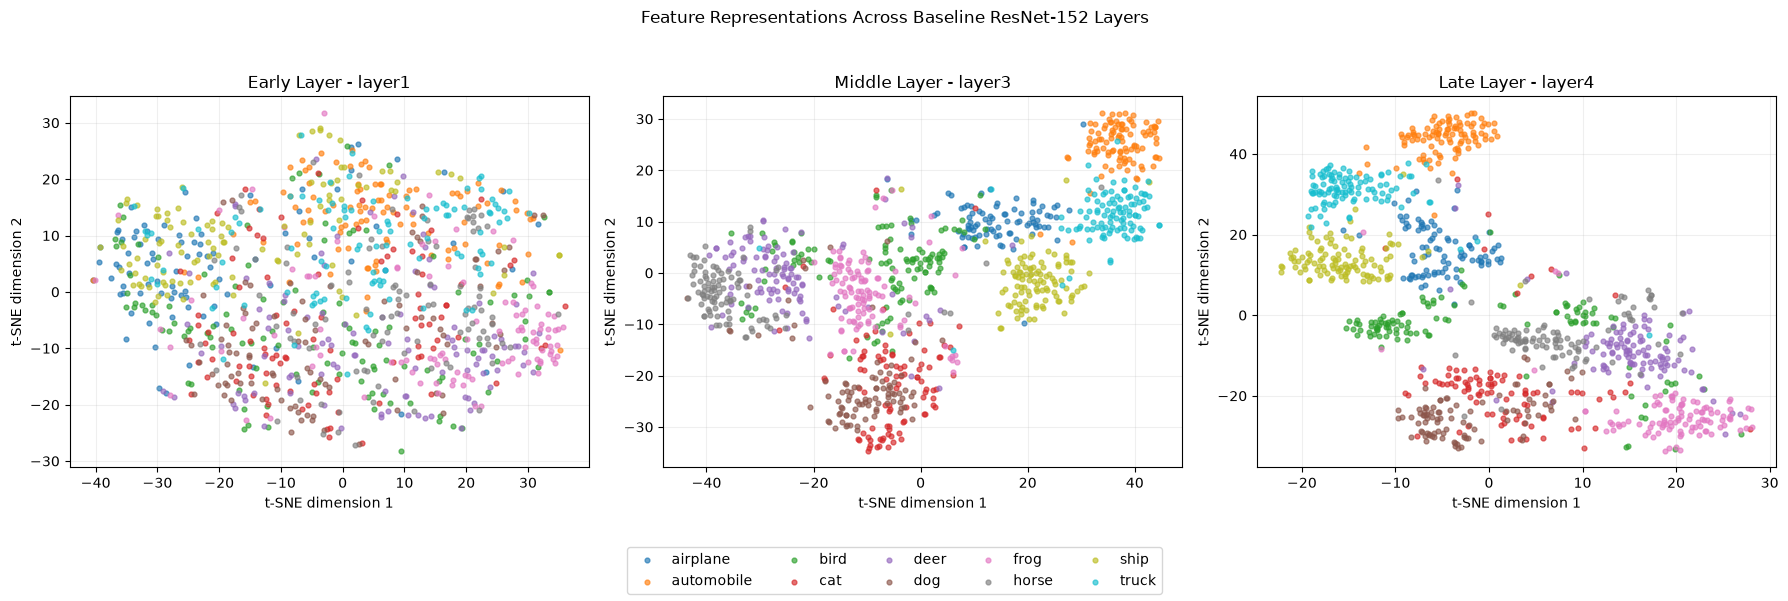

In [37]:
# Visualizes t-SNE embeddings for all selected layers.
# Colors points by CIFAR-10 class to compare separability.
layer_titles = {
    "early": "Early Layer - layer1",
    "middle": "Middle Layer - layer3",
    "late": "Late Layer - layer4"}

fig, axes = plt.subplots(1,3,figsize=(18, 6))
for axis, layer_name in zip(axes, layer_order):
    embedding = tsne_results[layer_name]
    for class_id, class_name in enumerate(class_names):
        class_mask = feature_labels == class_id
        axis.scatter(embedding[class_mask, 0],embedding[class_mask, 1],s=12,alpha=0.65,label=class_name)

    axis.set_title(layer_titles[layer_name])
    axis.set_xlabel("t-SNE dimension 1")
    axis.set_ylabel("t-SNE dimension 2")
    axis.grid(alpha=0.2)

legend_handles, legend_labels = (axes[0].get_legend_handles_labels())
fig.legend(legend_handles,legend_labels,loc="lower center",ncol=5)
plt.suptitle("Feature Representations Across Baseline ResNet-152 Layers")
plt.tight_layout(rect=[0, 0.12, 1, 0.95])
plt.show()

In [38]:
# Computes silhouette scores for each feature layer.
# Measures class separability in the PCA feature space.
separability_scores = {}
for layer_name in layer_order:
    score = silhouette_score(
        pca_results[layer_name],
        feature_labels)
    
    separability_scores[layer_name] = score
    print(
        f"{layer_name.capitalize():<8} "
        f"silhouette score: {score:.4f}")

Early    silhouette score: -0.0367
Middle   silhouette score: 0.0711
Late     silhouette score: 0.0467


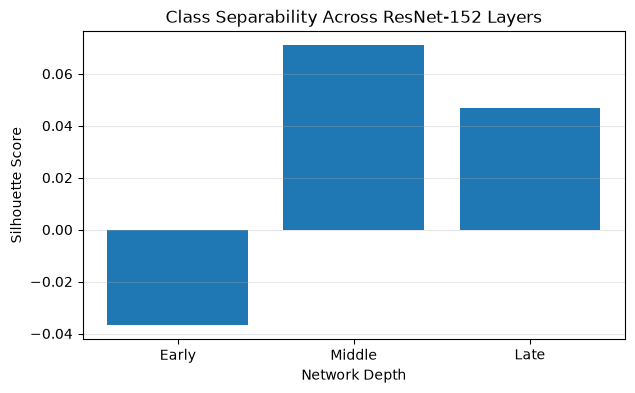

In [39]:
# Plots silhouette scores across network depth.
# Summarizes how feature separability changes by layer.
layer_names_for_plot = [
    "Early",
    "Middle",
    "Late"]

score_values = [
    separability_scores["early"],
    separability_scores["middle"],
    separability_scores["late"]]

plt.figure(figsize=(7, 4))
plt.bar(layer_names_for_plot,score_values)
plt.xlabel("Network Depth")
plt.ylabel("Silhouette Score")
plt.title("Class Separability Across ResNet-152 Layers")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [40]:
# Saves feature-analysis arrays to a compressed file.
# Stores labels, feature vectors, and t-SNE embeddings.
feature_analysis_dir = Path("./feature_analysis")
feature_analysis_dir.mkdir(exist_ok=True)
feature_results_path = (feature_analysis_dir / "baseline_feature_representations.npz")

np.savez_compressed(
    feature_results_path,
    labels=feature_labels,
    early_features=features["early"],
    middle_features=features["middle"],
    late_features=features["late"],
    early_tsne=tsne_results["early"],
    middle_tsne=tsne_results["middle"],
    late_tsne=tsne_results["late"])

print(
    "Feature-analysis results saved to:",
    feature_results_path)

Feature-analysis results saved to: feature_analysis\baseline_feature_representations.npz


In [41]:
# Moves the baseline model back to CPU.
# Clears GPU memory before the transfer-learning section.
baseline_model = baseline_model.to("cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Baseline model moved back to CPU.")

Baseline model moved back to CPU.


## 4) Transfer Learning and Generalization

In [42]:
# Prepares the GPU for transfer-learning experiments.
# Moves earlier models away from GPU memory if present.
if "model" in globals():
    model.to("cpu")

if "baseline_model" in globals():
    baseline_model.to("cpu")

if "modified_model" in globals():
    modified_model.to("cpu")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Device:", device)

Device: cuda


In [43]:
# Creates training and evaluation transforms for Flowers102.
# Uses ImageNet normalization for ResNet-152 transfer learning.
transfer_weights = ResNet152_Weights.DEFAULT
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]
flower_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        224,
        scale=(0.70, 1.0),
        interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std)])

flower_eval_transform = transfer_weights.transforms()
print("Training and evaluation transforms created.")

Training and evaluation transforms created.


In [44]:
# Downloads and prepares the Flowers102 splits.
# Creates train, validation, and test datasets for Task 4.
flower_train_dataset = datasets.Flowers102(root="../Data",split="train",download=True,transform=flower_train_transform)
flower_val_dataset = datasets.Flowers102(root="../Data",split="val",download=True,transform=flower_eval_transform)
flower_test_dataset = datasets.Flowers102(root="../Data",split="test",download=True,transform=flower_eval_transform)
num_flower_classes = 102

print("Training images:", len(flower_train_dataset))
print("Validation images:", len(flower_val_dataset))
print("Test images:", len(flower_test_dataset))
print("Number of classes:", num_flower_classes)

Training images: 1020
Validation images: 1020
Test images: 6149
Number of classes: 102


In [45]:
# Creates Flowers102 DataLoaders for all splits.
# Uses the selected batch size and GPU pinning when available.
flower_batch_size = 8
flower_train_loader = DataLoader(flower_train_dataset,batch_size=flower_batch_size,shuffle=True,num_workers=0,pin_memory=device.type == "cuda")
flower_val_loader = DataLoader(flower_val_dataset,batch_size=flower_batch_size,shuffle=False,num_workers=0,pin_memory=device.type == "cuda")
flower_test_loader = DataLoader(flower_test_dataset,batch_size=flower_batch_size,shuffle=False,num_workers=0,pin_memory=device.type == "cuda")
print("Data loaders created.")

Data loaders created.


In [46]:
# Loads one Flowers102 batch for inspection.
# Prints tensor shapes and normalized value ranges.
flower_images, flower_labels = next(iter(flower_train_loader))
print("Image batch shape:", flower_images.shape)
print("Label batch shape:", flower_labels.shape)
print("Minimum value:", flower_images.min().item())
print("Maximum value:", flower_images.max().item())

Image batch shape: torch.Size([8, 3, 224, 224])
Label batch shape: torch.Size([8])
Minimum value: -2.1179039478302
Maximum value: 2.640000104904175


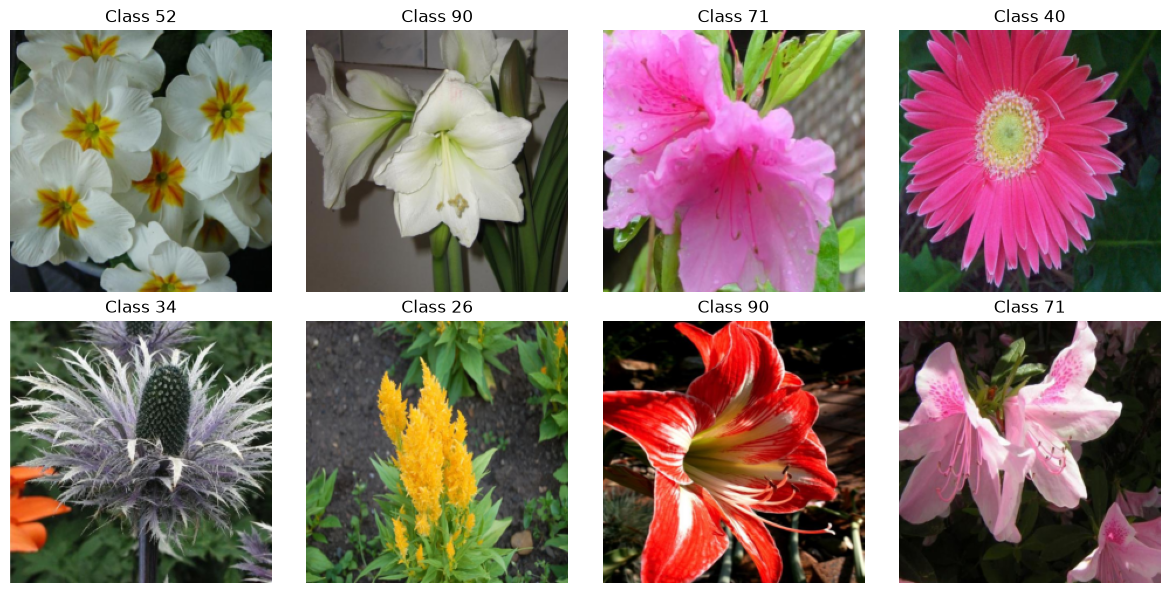

In [47]:
# Displays a few Flowers102 training examples.
# Unnormalizes images before plotting them with labels.
mean_tensor = torch.tensor(imagenet_mean).view(3, 1, 1)
std_tensor = torch.tensor(imagenet_std).view(3, 1, 1)
plt.figure(figsize=(12, 6))

for position in range(min(8, len(flower_images))):
    image = flower_images[position]
    display_image = image * std_tensor + mean_tensor
    display_image = display_image.clamp(0, 1)
    display_image = display_image.permute(1, 2, 0)

    plt.subplot(2, 4, position + 1)
    plt.imshow(display_image)
    plt.title(f"Class {flower_labels[position].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
# Defines a helper for building transfer-learning models.
# Supports ImageNet/random initialization and fine-tuning modes.
def build_transfer_model(use_imagenet_weights,head_only,final_block_only=False):
    torch.manual_seed(42)
    if use_imagenet_weights:
        experiment_model = resnet152(weights=transfer_weights)
    else:
        experiment_model = resnet152(weights=None)

    number_of_features = (experiment_model.fc.in_features)
    torch.manual_seed(123)
    experiment_model.fc = nn.Linear(number_of_features,num_flower_classes)

    if head_only:
        for parameter in experiment_model.parameters():
            parameter.requires_grad = False

        for parameter in experiment_model.fc.parameters():
            parameter.requires_grad = True

    elif final_block_only:
        for parameter in experiment_model.parameters():
            parameter.requires_grad = False

        for parameter in experiment_model.layer4.parameters():
            parameter.requires_grad = True

        for parameter in experiment_model.fc.parameters():
            parameter.requires_grad = True

    else:
        for parameter in experiment_model.parameters():
            parameter.requires_grad = True

    return experiment_model

In [49]:
# Defines one train or evaluation pass for Flowers102.
# Uses mixed precision on GPU and returns loss plus accuracy.
def run_flower_epoch(experiment_model,data_loader,criterion,optimizer=None,scaler=None,training=False,head_only=False,final_block_only=False):
    if training:
        if head_only:
            experiment_model.eval()
            experiment_model.fc.train()
        elif final_block_only:
            experiment_model.eval()
            experiment_model.layer4.train()
            experiment_model.fc.train()
        else:
            experiment_model.train()
    else:
        experiment_model.eval()

    total_loss = 0.0
    total_correct = 0
    total_images = 0
    use_amp = device.type == "cuda" and not final_block_only

    for images, labels in data_loader:
        images = images.to(device,non_blocking=True)
        labels = labels.to(device,non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.autocast(device_type=device.type,dtype=torch.float16,enabled=use_amp):
                outputs = experiment_model(images)
                loss = criterion(outputs, labels)

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        predictions = outputs.argmax(dim=1)
        total_loss += (loss.item() * images.size(0))
        total_correct += (predictions == labels).sum().item()
        total_images += labels.size(0)

    average_loss = total_loss / total_images
    accuracy = total_correct / total_images
    return average_loss, accuracy

In [50]:
# Creates the transfer-learning progress folder.
# Stores checkpoints and best weights for all Task 4 models.
transfer_progress_dir = Path("./transfer_learning_progress_model_3_4_5_6")
transfer_progress_dir.mkdir(parents=True,exist_ok=True)

In [51]:
# Defines the checkpointed training helper for Task 4.
# Handles resume, validation tracking, best-model saving, and history.

def train_transfer_experiment(experiment_model,experiment_name,head_only,epochs,learning_rate,final_block_only=False):
    experiment_model = experiment_model.to(device)
    criterion = nn.CrossEntropyLoss()
    trainable_parameters = [parameter
        for parameter in experiment_model.parameters()
        if parameter.requires_grad]

    optimizer = torch.optim.AdamW(trainable_parameters,lr=learning_rate,weight_decay=1e-4)
    use_amp = device.type == "cuda" and not final_block_only
    scaler = torch.amp.GradScaler("cuda",enabled=use_amp)
    checkpoint_path = (transfer_progress_dir / f"{experiment_name}_checkpoint.pth")
    best_model_path = (transfer_progress_dir / f"{experiment_name}_best.pth")

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "epoch_seconds": []}

    start_epoch = 0
    best_val_accuracy = 0.0
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path,map_location=device)

        experiment_model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])

        if "scaler_state" in checkpoint:
            scaler.load_state_dict(checkpoint["scaler_state"])

        history = checkpoint["history"]
        start_epoch = checkpoint["epoch"] + 1
        best_val_accuracy = checkpoint.get("best_val_accuracy",0.0)

        print(
            f"Resuming {experiment_name} "
            f"from epoch {start_epoch + 1}")

    total_parameters = sum(parameter.numel()
        for parameter in experiment_model.parameters())

    trainable_count = sum(parameter.numel()
        for parameter in experiment_model.parameters()
        if parameter.requires_grad)

    print("Experiment:", experiment_name)
    print(f"Total parameters: {total_parameters:,}")
    print(f"Trainable parameters: {trainable_count:,}")

    if start_epoch >= epochs:
        print("Experiment is already complete.")
        return experiment_model, history

    for epoch in range(start_epoch, epochs):
        epoch_start = time.perf_counter()
        train_loss, train_accuracy = run_flower_epoch(experiment_model=experiment_model,data_loader=flower_train_loader,criterion=criterion,optimizer=optimizer,scaler=scaler,training=True,head_only=head_only,final_block_only=final_block_only)

        val_loss, val_accuracy = run_flower_epoch(experiment_model=experiment_model,data_loader=flower_val_loader,criterion=criterion,training=False,head_only=head_only,final_block_only=final_block_only)

        epoch_seconds = (time.perf_counter() - epoch_start)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)
        history["epoch_seconds"].append(epoch_seconds)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy

            torch.save(experiment_model.state_dict(),best_model_path)

        torch.save({
                "epoch": epoch,
                "model_state":
                    experiment_model.state_dict(),
                "optimizer_state":
                    optimizer.state_dict(),
                "scaler_state":
                    scaler.state_dict(),
                "history": history,
                "best_val_accuracy":
                    best_val_accuracy},
                    checkpoint_path)

        print(f"\nEpoch {epoch + 1}/{epochs}")
        print(f"Train - Loss: {train_loss:.4f}, "
            f"Accuracy: {train_accuracy * 100:.2f}%")
        print(f"Val   - Loss: {val_loss:.4f}, "
            f"Accuracy: {val_accuracy * 100:.2f}%")

        print(f"Time: {epoch_seconds:.1f} seconds")
        print(f"Best validation accuracy: "
            f"{best_val_accuracy * 100:.2f}%")

    return experiment_model, history

In [52]:
# Defines the shared Task 4 training settings.
# Prints epochs and learning rate used by the experiments.
transfer_epochs = 10
full_learning_rate = 1e-4
print("Epochs:", transfer_epochs)
print("Fine-tuning learning rate:", full_learning_rate)

Epochs: 10
Fine-tuning learning rate: 0.0001


In [53]:
# Builds the ImageNet-initialized final-block model.
# Only the final block and classifier are trainable.
pretrained_final_block_model = build_transfer_model(use_imagenet_weights=True,head_only=False,final_block_only=True)
print("Pretrained final-block model created.")

Pretrained final-block model created.


In [54]:
# Trains or resumes the ImageNet final-block experiment.
# Stores its returned model and training history.
pretrained_final_block_model, pretrained_final_block_history = (train_transfer_experiment(experiment_model=pretrained_final_block_model,experiment_name="pretrained_final_block",head_only=False,epochs=transfer_epochs,learning_rate=full_learning_rate,final_block_only=True))

Resuming pretrained_final_block from epoch 11
Experiment: pretrained_final_block
Total parameters: 58,352,806
Trainable parameters: 15,173,734
Experiment is already complete.


In [55]:
# Moves the ImageNet final-block model back to CPU.
# Clears GPU memory before starting the next experiment.
pretrained_final_block_model.to("cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Pretrained final-block model moved to CPU.")

Pretrained final-block model moved to CPU.


In [56]:
# Builds the random-initialized final-block model.
# Only the final block and classifier are trainable.
random_final_block_model = build_transfer_model(use_imagenet_weights=False,head_only=False,final_block_only=True)
print("Random final-block model created.")

Random final-block model created.


In [57]:
# Trains or resumes the random final-block experiment.
# Stores its returned model and training history.
random_final_block_model, random_final_block_history = (train_transfer_experiment(experiment_model=random_final_block_model,experiment_name="random_final_block",head_only=False,epochs=transfer_epochs,learning_rate=full_learning_rate,final_block_only=True))

Resuming random_final_block from epoch 11
Experiment: random_final_block
Total parameters: 58,352,806
Trainable parameters: 15,173,734
Experiment is already complete.


In [58]:
# Moves the random final-block model back to CPU.
# Clears GPU memory before starting the next experiment.
random_final_block_model.to("cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Random final-block model moved to CPU.")

Random final-block model moved to CPU.


In [59]:
# Builds the ImageNet-initialized full-network model.
# All ResNet parameters are trainable for fine-tuning.
pretrained_full_model = build_transfer_model(use_imagenet_weights=True,head_only=False)
print("Pretrained full-network model created.")

Pretrained full-network model created.


In [60]:
# Trains or resumes the ImageNet full-network experiment.
# Stores its returned model and training history.
pretrained_full_model, pretrained_full_history = (train_transfer_experiment(experiment_model=pretrained_full_model,experiment_name="pretrained_full_network",head_only=False,epochs=transfer_epochs,learning_rate=full_learning_rate))

Resuming pretrained_full_network from epoch 11
Experiment: pretrained_full_network
Total parameters: 58,352,806
Trainable parameters: 58,352,806
Experiment is already complete.


In [61]:
# Moves the ImageNet full-network model back to CPU.
# Clears GPU memory before starting the next experiment.
pretrained_full_model.to("cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Pretrained full model moved to CPU.")

Pretrained full model moved to CPU.


In [62]:
# Builds the random-initialized full-network model.
# All ResNet parameters are trainable from scratch.
random_full_model = build_transfer_model(use_imagenet_weights=False,head_only=False)
print("Random full-network model created.")

Random full-network model created.


In [63]:
# Trains or resumes the random full-network experiment.
# Stores its returned model and training history.
random_full_model, random_full_history = (train_transfer_experiment(experiment_model=random_full_model,experiment_name="random_full_network",head_only=False,epochs=transfer_epochs,learning_rate=full_learning_rate))

Resuming random_full_network from epoch 11
Experiment: random_full_network
Total parameters: 58,352,806
Trainable parameters: 58,352,806
Experiment is already complete.


In [64]:
# Moves the random full-network model back to CPU.
# Clears GPU memory before result comparison.
random_full_model.to("cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Random full model moved to CPU.")

Random full model moved to CPU.


In [65]:
# Combines histories from all transfer-learning runs.
# Prints validation accuracy, loss, and total training time.

all_histories = {
    "ImageNet - final block":
        pretrained_final_block_history,
    "Random - final block":
        random_final_block_history,
    "ImageNet - full network":
        pretrained_full_history,
    "Random - full network":
        random_full_history}

print(
    f"{'Experiment':<30}"
    f"{'Best Val Acc':<18}"
    f"{'Final Val Loss':<18}"
    f"{'Training Time':<18}")
print("-" * 84)

for experiment_name, experiment_history in all_histories.items():
    best_accuracy = max(experiment_history["val_accuracy"]) * 100
    final_loss = (experiment_history["val_loss"][-1])
    total_seconds = sum(experiment_history["epoch_seconds"])
    print(
        f"{experiment_name:<30}"
        f"{best_accuracy:<18.2f}"
        f"{final_loss:<18.4f}"
        f"{total_seconds:<18.1f}")

Experiment                    Best Val Acc      Final Val Loss    Training Time     
------------------------------------------------------------------------------------
ImageNet - final block        91.76             0.3323            225.5             
Random - final block          2.65              4.9149            218.7             
ImageNet - full network       93.53             0.2675            307.9             
Random - full network         10.49             3.8695            300.6             


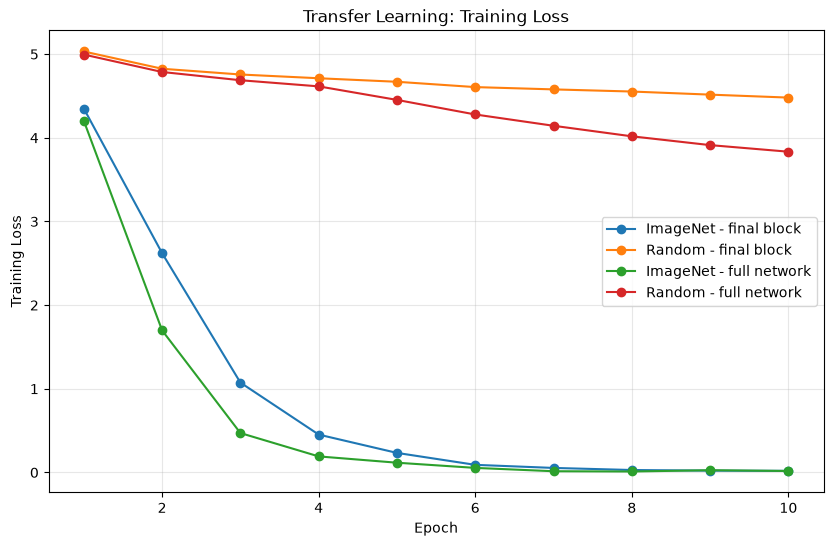

In [66]:
# Plots training loss for all transfer experiments.
# Compares how each Task 4 model reduces loss across epochs.
plt.figure(figsize=(10, 6))
for experiment_name, experiment_history in all_histories.items():
    epoch_numbers = range(1,len(experiment_history["train_loss"]) + 1)
    plt.plot(epoch_numbers,experiment_history["train_loss"],marker="o",label=experiment_name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Transfer Learning: Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

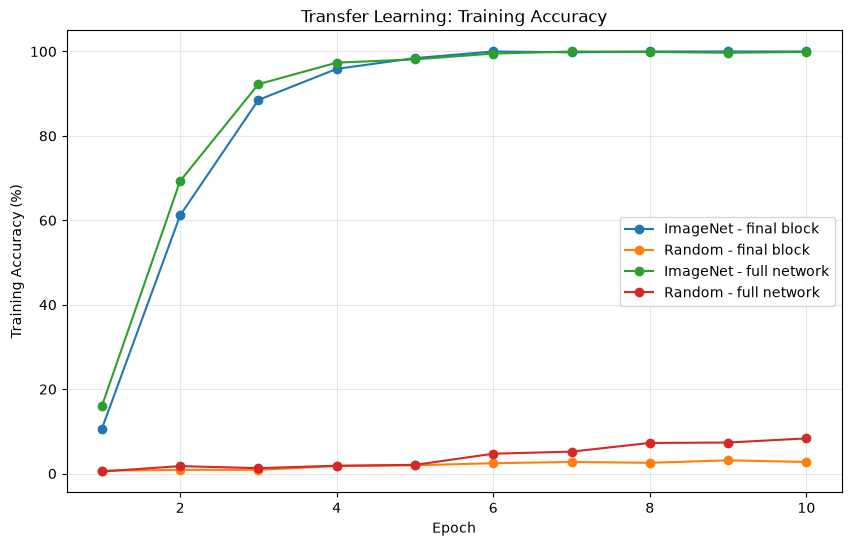

In [67]:
# Plots training accuracy for all transfer experiments.
# Compares how each Task 4 model learns on the Flowers102 train split.
plt.figure(figsize=(10, 6))
for experiment_name, experiment_history in all_histories.items():
    epoch_numbers = range(1,len(experiment_history["train_accuracy"]) + 1)
    training_accuracy = [accuracy * 100
        for accuracy in experiment_history["train_accuracy"]]

    plt.plot(epoch_numbers,training_accuracy,marker="o",label=experiment_name)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Transfer Learning: Training Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

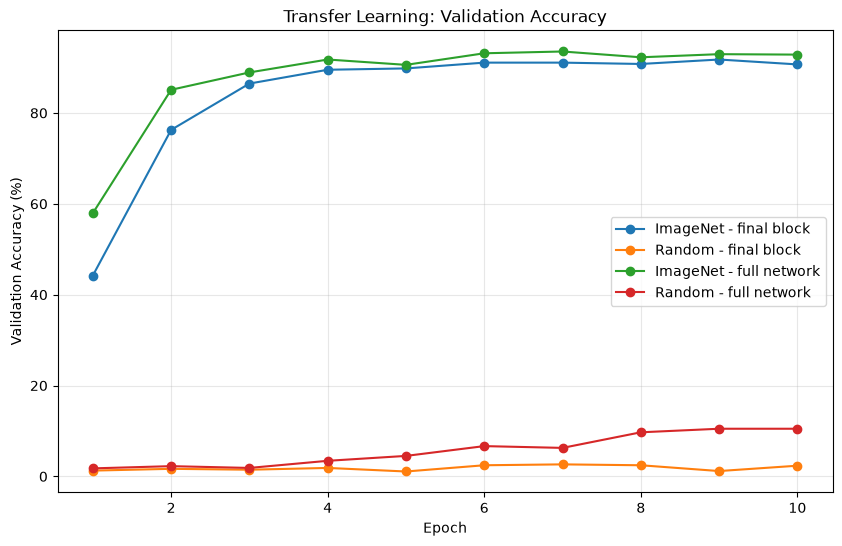

In [68]:
# Plots validation accuracy for all transfer experiments.
# Compares learning progress across epochs.

plt.figure(figsize=(10, 6))
for experiment_name, experiment_history in all_histories.items():
    epoch_numbers = range(1,len(experiment_history["val_accuracy"]) + 1)
    validation_accuracy = [accuracy * 100
        for accuracy in experiment_history["val_accuracy"]]

    plt.plot(epoch_numbers,validation_accuracy,marker="o",label=experiment_name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Transfer Learning: Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

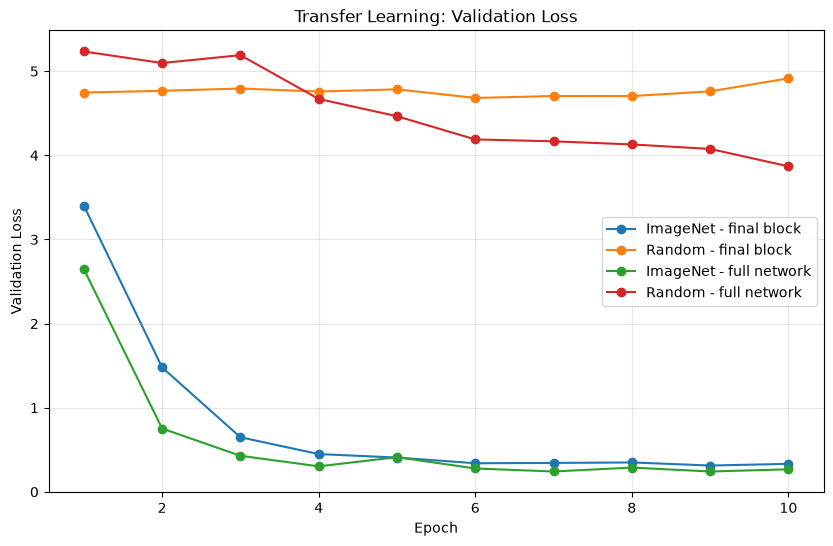

In [69]:
# Plots validation loss for all transfer experiments.
# Shows convergence behavior for each training setting.
plt.figure(figsize=(10, 6))
for experiment_name, experiment_history in all_histories.items():
    epoch_numbers = range(1,len(experiment_history["val_loss"]) + 1)
    plt.plot(epoch_numbers,experiment_history["val_loss"],marker="o",label=experiment_name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Transfer Learning: Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [70]:
# Defines a helper for evaluating saved best models.
# Loads best weights and computes Flowers102 test metrics.
def evaluate_best_flower_model(experiment_name,use_imagenet_weights,head_only,final_block_only=False):
    best_model_path = (transfer_progress_dir /f"{experiment_name}_best.pth")
    evaluation_model = build_transfer_model(use_imagenet_weights=use_imagenet_weights,head_only=head_only,final_block_only=final_block_only)
    best_state = torch.load(best_model_path,map_location=device)
    evaluation_model.load_state_dict(best_state)
    evaluation_model = evaluation_model.to(device)
    criterion = nn.CrossEntropyLoss()
    test_loss, test_accuracy = run_flower_epoch(experiment_model=evaluation_model,data_loader=flower_test_loader,criterion=criterion,training=False,head_only=head_only,final_block_only=final_block_only)
    evaluation_model.to("cpu")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return test_loss, test_accuracy

In [71]:
# Evaluates every transfer-learning experiment on the test set.
# Prints final test loss and test accuracy for comparison.
test_results = {}
test_results["ImageNet - final block"] = (evaluate_best_flower_model(experiment_name="pretrained_final_block",use_imagenet_weights=True,head_only=False,final_block_only=True))
test_results["Random - final block"] = (evaluate_best_flower_model(experiment_name="random_final_block",use_imagenet_weights=False,head_only=False,final_block_only=True))
test_results["ImageNet - full network"] = (evaluate_best_flower_model(experiment_name="pretrained_full_network",use_imagenet_weights=True,head_only=False))
test_results["Random - full network"] = (evaluate_best_flower_model(experiment_name="random_full_network",use_imagenet_weights=False,head_only=False))
print(f"{'Experiment':<30}"
    f"{'Test Loss':<16}"
    f"{'Test Accuracy':<16}")
print("-" * 62)

for experiment_name, result in test_results.items():
    test_loss, test_accuracy = result
    print(
        f"{experiment_name:<30}"
        f"{test_loss:<16.4f}"
        f"{test_accuracy * 100:<16.2f}")

Experiment                    Test Loss       Test Accuracy   
--------------------------------------------------------------
ImageNet - final block        0.3303          91.69           
Random - final block          4.7135          2.70            
ImageNet - full network       0.3437          90.80           
Random - full network         4.0983          8.47            


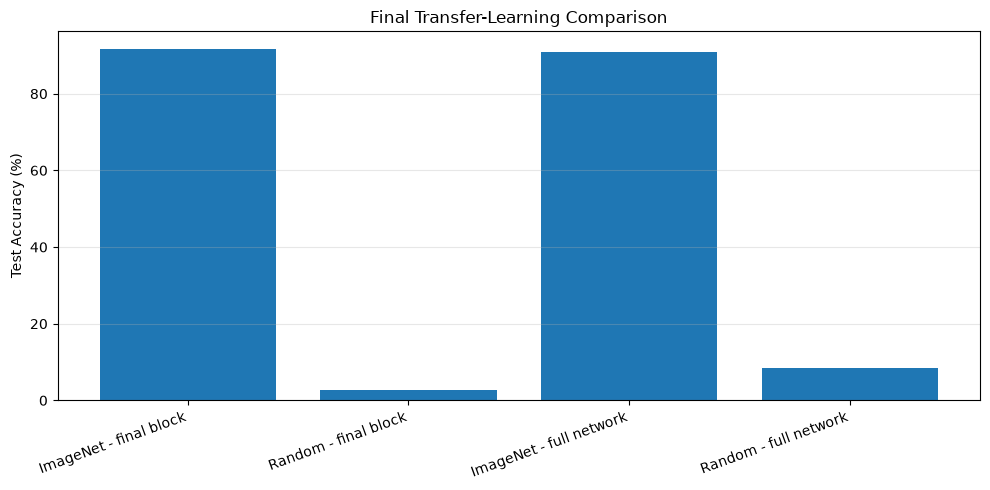

In [72]:
# Plots final test accuracy for all Task 4 experiments.
# Provides a compact visual comparison of model performance.
experiment_names = list(test_results.keys())
test_accuracies = [test_results[name][1] * 100
    for name in experiment_names]
plt.figure(figsize=(10, 5))
plt.bar(experiment_names,test_accuracies)
plt.ylabel("Test Accuracy (%)")
plt.title("Final Transfer-Learning Comparison")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
# Finds and prints the best transfer-learning experiment.
# Also reports the random-guessing baseline for Flowers102.
best_experiment = max(test_results,key=lambda name: test_results[name][1])
best_test_accuracy = (test_results[best_experiment][1] * 100)
print("Best experiment:", best_experiment)
print(
    f"Best test accuracy: "
    f"{best_test_accuracy:.2f}%")
print(
    f"Random guessing accuracy for "
    f"{num_flower_classes} classes: "
    f"{100 / num_flower_classes:.2f}%")

Best experiment: ImageNet - final block
Best test accuracy: 91.69%
Random guessing accuracy for 102 classes: 0.98%


# EXTRA EXPERIMENTS for visulizations

In [79]:
# Sets up short full-network runs for gradient-flow visualization.
# Uses fresh baseline and no-skip ResNet-152 models on CIFAR-10.
gradient_epochs = 10
gradient_batch_size = 8
gradient_batches_per_epoch = 50
gradient_learning_rate = 1e-5
gradient_layer_names = ["conv1","layer1","layer2","layer3","layer4","fc"]
gradient_train_loader = DataLoader(train_dataset,batch_size=gradient_batch_size,shuffle=True,num_workers=0)

def build_gradient_model(remove_skips=False):
    torch.manual_seed(42)
    gradient_model = resnet152(weights=weights)
    number_of_features = gradient_model.fc.in_features
    gradient_model.fc = nn.Linear(number_of_features,10)

    if remove_skips:
        gradient_selected_blocks = {
            "layer2_last": gradient_model.layer2[-1],
            "layer4_last": gradient_model.layer4[-1],}
        for block_name, block in gradient_selected_blocks.items():
            block.forward = MethodType(forward_without_skip,block)
            print("Skip connection disabled in:", block_name)

    for parameter in gradient_model.parameters():
        parameter.requires_grad = True

    return gradient_model.to(device)

print("Gradient epochs:", gradient_epochs)
print("Gradient batch size:", gradient_batch_size)
print("Batches per epoch:", gradient_batches_per_epoch)

Gradient epochs: 10
Gradient batch size: 8
Batches per epoch: 50


In [80]:
# Defines helpers to record gradient norms during training.
# Stores average gradient strength for major ResNet stages.
def get_gradient_norms(gradient_model):
    gradient_norms = {}
    for layer_name in gradient_layer_names:
        layer = getattr(gradient_model,layer_name)
        layer_norms = []
        for parameter in layer.parameters():
            if parameter.grad is not None:
                layer_norms.append(parameter.grad.detach().norm().item())

        if len(layer_norms) == 0:
            gradient_norms[layer_name] = 0.0
        else:
            gradient_norms[layer_name] = sum(layer_norms) / len(layer_norms)

    return gradient_norms

def train_gradient_model(gradient_model,experiment_name):
    gradient_criterion = nn.CrossEntropyLoss()
    gradient_optimizer = torch.optim.AdamW(gradient_model.parameters(),lr=gradient_learning_rate,weight_decay=1e-4)
    gradient_history = {
        "train_loss": [],
        "train_accuracy": [],
        "gradient_norms": []}

    for epoch in range(gradient_epochs):
        gradient_model.train()
        total_loss = 0.0
        total_correct = 0
        total_images = 0
        epoch_gradient_norms = {layer_name: [] for layer_name in gradient_layer_names}

        for batch_index, (images, labels) in enumerate(gradient_train_loader):
            if batch_index >= gradient_batches_per_epoch:
                break

            images = images.to(device)
            labels = labels.to(device)
            gradient_optimizer.zero_grad()
            outputs = gradient_model(images)
            loss = gradient_criterion(outputs,labels)
            loss.backward()

            current_gradient_norms = get_gradient_norms(gradient_model)
            for layer_name in gradient_layer_names:
                epoch_gradient_norms[layer_name].append(current_gradient_norms[layer_name])

            gradient_optimizer.step()
            predictions = outputs.argmax(dim=1)
            total_loss += loss.item() * images.size(0)
            total_correct += (predictions == labels).sum().item()
            total_images += labels.size(0)

        average_loss = total_loss / total_images
        accuracy = total_correct / total_images
        average_gradient_norms = {}
        for layer_name in gradient_layer_names:
            average_gradient_norms[layer_name] = sum(epoch_gradient_norms[layer_name]) / len(epoch_gradient_norms[layer_name])

        gradient_history["train_loss"].append(average_loss)
        gradient_history["train_accuracy"].append(accuracy)
        gradient_history["gradient_norms"].append(average_gradient_norms)

        print(f"{experiment_name} | Epoch {epoch + 1}/{gradient_epochs}")
        print(f"Train Loss: {average_loss:.4f}, Train Accuracy: {accuracy * 100:.2f}%")

    gradient_model.to("cpu")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return gradient_history

In [81]:
# Trains the fully trainable baseline model for gradient visualization.
# Keeps normal ResNet skip connections enabled.
gradient_baseline_model = build_gradient_model(remove_skips=False)
gradient_baseline_history = train_gradient_model(gradient_baseline_model,"Baseline gradient model")

Baseline gradient model | Epoch 1/10
Train Loss: 2.2998, Train Accuracy: 10.75%
Baseline gradient model | Epoch 2/10
Train Loss: 2.2827, Train Accuracy: 13.25%
Baseline gradient model | Epoch 3/10
Train Loss: 2.2401, Train Accuracy: 21.75%
Baseline gradient model | Epoch 4/10
Train Loss: 2.1887, Train Accuracy: 27.50%
Baseline gradient model | Epoch 5/10
Train Loss: 2.1297, Train Accuracy: 37.50%
Baseline gradient model | Epoch 6/10
Train Loss: 2.0700, Train Accuracy: 46.00%
Baseline gradient model | Epoch 7/10
Train Loss: 1.9638, Train Accuracy: 59.25%
Baseline gradient model | Epoch 8/10
Train Loss: 1.8299, Train Accuracy: 59.50%
Baseline gradient model | Epoch 9/10
Train Loss: 1.6963, Train Accuracy: 60.00%
Baseline gradient model | Epoch 10/10
Train Loss: 1.4819, Train Accuracy: 69.75%


In [82]:
# Trains the fully trainable no-skip model for gradient visualization.
# Removes selected skip connections before the short training run.
gradient_noskip_model = build_gradient_model(remove_skips=True)
gradient_noskip_history = train_gradient_model(gradient_noskip_model,"No-skip gradient model")

Skip connection disabled in: layer2_last
Skip connection disabled in: layer4_last
No-skip gradient model | Epoch 1/10
Train Loss: 2.3012, Train Accuracy: 10.50%
No-skip gradient model | Epoch 2/10
Train Loss: 2.3007, Train Accuracy: 12.75%
No-skip gradient model | Epoch 3/10
Train Loss: 2.3016, Train Accuracy: 11.75%
No-skip gradient model | Epoch 4/10
Train Loss: 2.2973, Train Accuracy: 16.75%
No-skip gradient model | Epoch 5/10
Train Loss: 2.2991, Train Accuracy: 12.25%
No-skip gradient model | Epoch 6/10
Train Loss: 2.2963, Train Accuracy: 15.00%
No-skip gradient model | Epoch 7/10
Train Loss: 2.2962, Train Accuracy: 14.25%
No-skip gradient model | Epoch 8/10
Train Loss: 2.2933, Train Accuracy: 13.75%
No-skip gradient model | Epoch 9/10
Train Loss: 2.2917, Train Accuracy: 14.75%
No-skip gradient model | Epoch 10/10
Train Loss: 2.2913, Train Accuracy: 15.50%


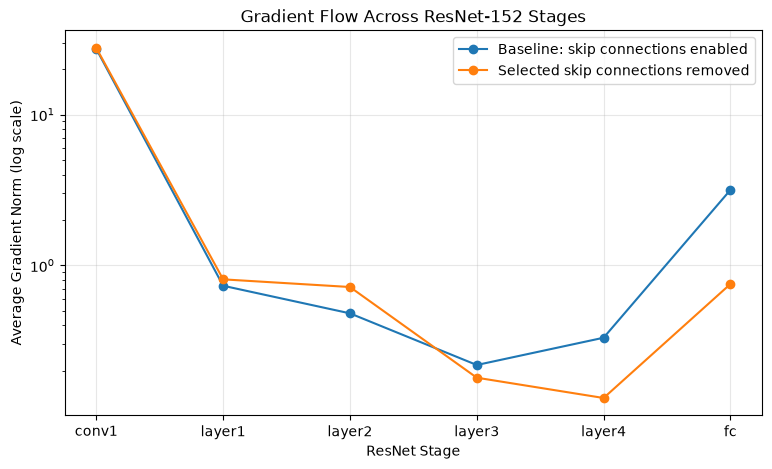

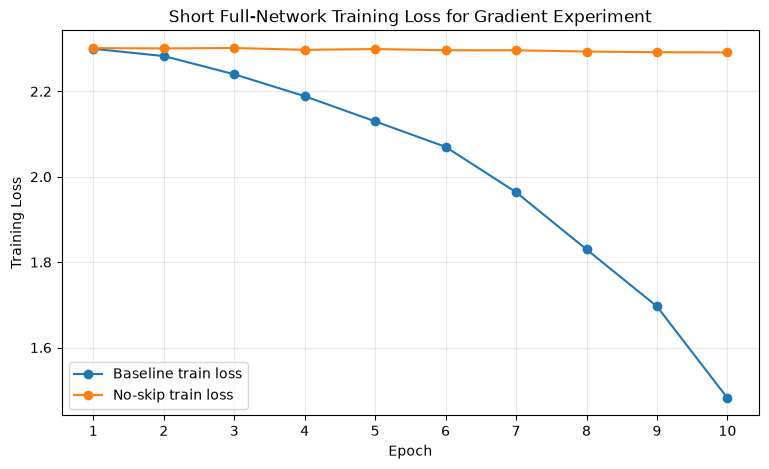

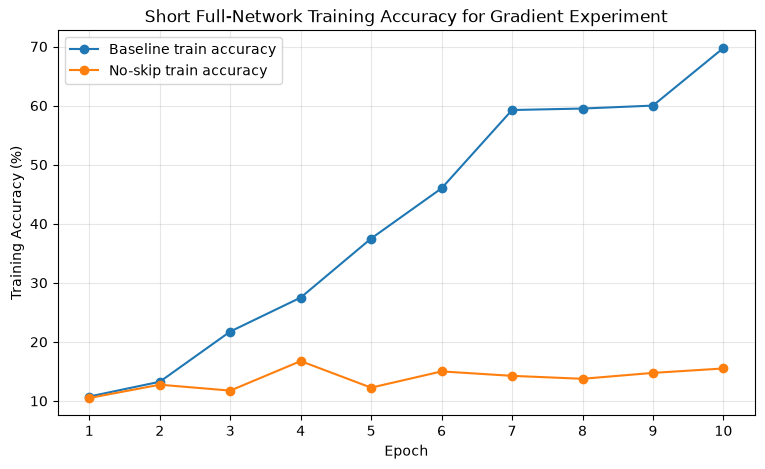

In [83]:
# Plots baseline and no-skip gradient flow across ResNet stages.
# Also compares short-run training loss and accuracy curves.
baseline_final_gradient_norms = gradient_baseline_history["gradient_norms"][-1]
noskip_final_gradient_norms = gradient_noskip_history["gradient_norms"][-1]
baseline_gradient_values = [baseline_final_gradient_norms[layer_name] for layer_name in gradient_layer_names]
noskip_gradient_values = [noskip_final_gradient_norms[layer_name] for layer_name in gradient_layer_names]

plt.figure(figsize=(9, 5))
plt.plot(gradient_layer_names,baseline_gradient_values,marker="o",label="Baseline: skip connections enabled")
plt.plot(gradient_layer_names,noskip_gradient_values,marker="o",label="Selected skip connections removed")
plt.yscale("log")
plt.xlabel("ResNet Stage")
plt.ylabel("Average Gradient Norm (log scale)")
plt.title("Gradient Flow Across ResNet-152 Stages")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

gradient_epoch_numbers = range(1,gradient_epochs + 1)
plt.figure(figsize=(9, 5))
plt.plot(gradient_epoch_numbers,gradient_baseline_history["train_loss"],marker="o",label="Baseline train loss")
plt.plot(gradient_epoch_numbers,gradient_noskip_history["train_loss"],marker="o",label="No-skip train loss")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Short Full-Network Training Loss for Gradient Experiment")
plt.xticks(gradient_epoch_numbers)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(gradient_epoch_numbers,[accuracy * 100 for accuracy in gradient_baseline_history["train_accuracy"]],marker="o",label="Baseline train accuracy")
plt.plot(gradient_epoch_numbers,[accuracy * 100 for accuracy in gradient_noskip_history["train_accuracy"]],marker="o",label="No-skip train accuracy")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Short Full-Network Training Accuracy for Gradient Experiment")
plt.xticks(gradient_epoch_numbers)
plt.legend()
plt.grid(alpha=0.3)
plt.show()